In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
load_path = Path("../../data/combined/done_week_45")

In [3]:
listing = pd.read_parquet(load_path/"listing.parquet")

In [4]:
listing.columns

Index(['OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'AssociationFeeFrequency', 'CountyOrParish', 'ParkingTotal',
       'PropertySubType', 'YearBuilt', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'StateOrProvince', 'FireplaceYN', 'Levels',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'PostalCode', 'AssociationFee', 'PurchaseContractDate',
       'ListingContractDate', 'ContractStatusChangeDate', 'rate_30yr_fixed',
       'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'listing_after_close_flag', 'purchase_after_close_flag',
       'geographic_error'],
      dtype='str')

In [5]:
fe_listing = listing.copy()

fe_listing["PriceRatio"] = np.where(
    fe_listing["OriginalListPrice"] > 0,
    fe_listing["ClosePrice"] / fe_listing["OriginalListPrice"],
    np.nan)
fe_listing["PricePerSqFt"] = np.where(
    fe_listing["LivingArea"] > 0,
    fe_listing["ClosePrice"] / fe_listing["LivingArea"],
    np.nan)

fe_listing["Year"] = fe_listing["CloseDate"].dt.year
fe_listing["Month"] = fe_listing["CloseDate"].dt.month
fe_listing["Year"] = fe_listing["Year"].astype('Int64')
fe_listing["Month"] = fe_listing["Month"].astype('Int64')
fe_listing["YrMo"] = fe_listing["Year"].astype(str) + "-" + fe_listing["Month"].astype(str)

fe_listing["ListingToContractDays"] = (fe_listing["PurchaseContractDate"] - fe_listing["ListingContractDate"]).dt.days
fe_listing["ContractToCloseDays"] = (fe_listing["CloseDate"] - fe_listing["PurchaseContractDate"]).dt.days
fe_listing["ListingToContractDays"] = fe_listing["ListingToContractDays"].astype('Int64')
fe_listing["ContractToCloseDays"] = fe_listing["ContractToCloseDays"].astype('Int64')

In [6]:
fe_listing[fe_listing["ClosePrice"].notna()]

,OriginalListPrice,CloseDate,ClosePrice,Latitude,Longitude,PropertyType,LivingArea,ListPrice,DaysOnMarket,AssociationFeeFrequency,...,listing_after_close_flag,purchase_after_close_flag,geographic_error,PriceRatio,PricePerSqFt,Year,Month,YrMo,ListingToContractDays,ContractToCloseDays
9,1249888.0,2024-05-01,1262555.0,33.477414,-117.664879,Residential,1899.0,1249888.0,0,Monthly,...,False,False,False,1.010135,664.852554,2024,5,2024-5,20,73
14,650000.0,2024-03-15,650000.0,35.508840,-120.690614,Residential,1400.0,650000.0,0,None,...,False,False,False,1.000000,464.285714,2024,3,2024-3,10,43
18,1025000.0,2024-05-02,962500.0,33.812886,-118.097004,Residential,1130.0,1025000.0,0,None,...,False,False,False,0.939024,851.769912,2024,5,2024-5,104,2
20,725000.0,2024-04-30,725000.0,33.740706,-117.888816,Residential,1250.0,725000.0,0,None,...,False,False,False,1.000000,580.000000,2024,4,2024-4,18,81
33,730000.0,2024-04-09,730000.0,NaN,NaN,Residential,1266.0,730000.0,35,None,...,False,False,True,1.000000,576.619273,2024,4,2024-4,35,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563719,2384000.0,2026-05-01,2650000.0,37.817147,-121.980675,Residential,2696.0,2384000.0,8,Quarterly,...,False,False,False,1.111577,982.937685,2026,5,2026-5,8,15
563726,1695000.0,2026-05-06,1827000.0,37.671712,-121.759595,Residential,2310.0,1695000.0,14,Monthly,...,False,False,False,1.077876,790.909091,2026,5,2026-5,14,21
563739,1100000.0,2026-05-05,1050000.0,33.195432,-117.218856,Residential,1659.0,1100000.0,16,None,...,False,False,False,0.954545,632.911392,2026,5,2026-5,0,30
563749,1278000.0,2026-04-27,1320000.0,37.953455,-122.002616,Residential,3035.0,1278000.0,3,None,...,False,False,False,1.032864,434.925865,2026,4,2026-4,3,14


<Axes: ylabel='PropertySubType'>

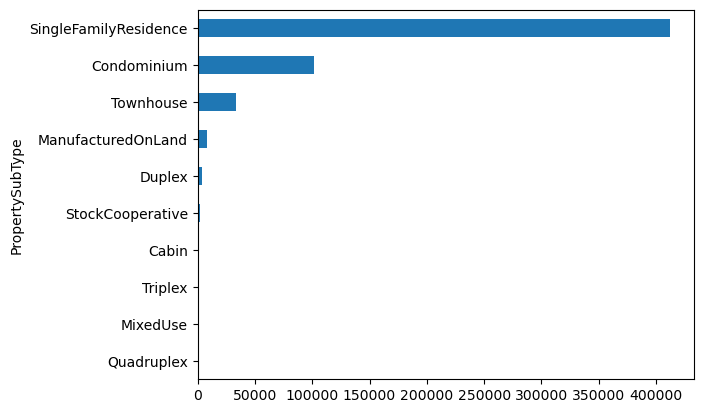

In [7]:
fe_listing["PropertySubType"].value_counts().head(10).sort_values().plot.barh()

<Axes: ylabel='CountyOrParish'>

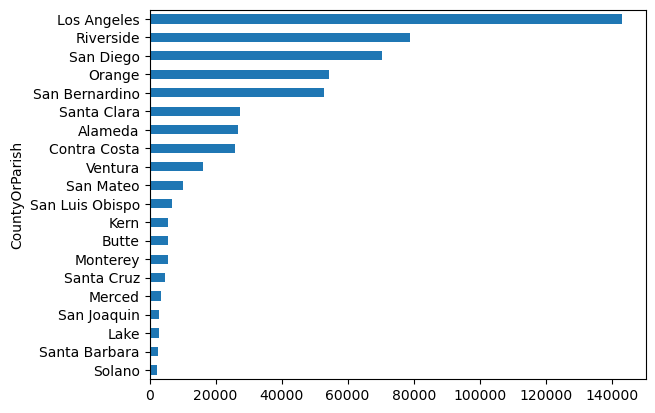

In [8]:
fe_listing["CountyOrParish"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='MLSAreaMajor'>

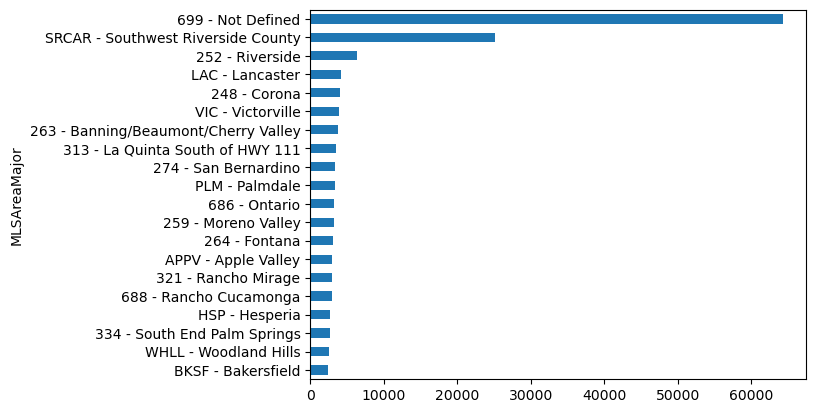

In [9]:
fe_listing["MLSAreaMajor"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='ListOfficeName'>

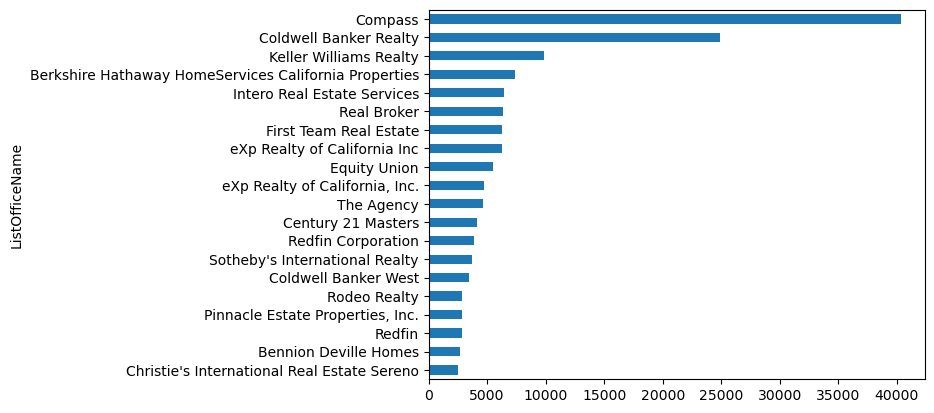

In [10]:
fe_listing["ListOfficeName"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='BuyerOfficeName'>

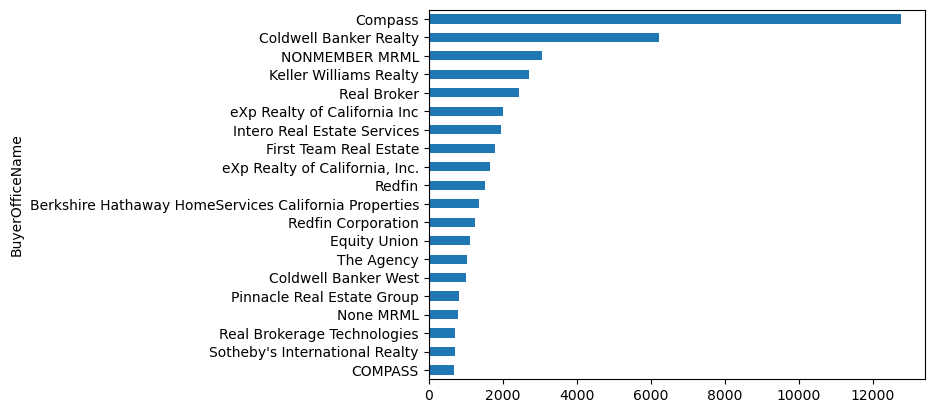

In [11]:
fe_listing["BuyerOfficeName"].value_counts().head(20).sort_values().plot.barh()

In [12]:
summary_by_PropertySubType = (
    fe_listing
    .groupby("PropertySubType")
    .agg(
        listing_count=("PropertySubType", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_PropertySubType.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
PropertySubType,,,,,,,,
SingleFamilyResidence,412229,1.305902e+06,935000.0,654.052742,44.121377,18.568184,22.378775,26.612464
Condominium,101195,8.807308e+05,639000.0,705.916042,27.572856,21.058392,25.84438,26.200483
Townhouse,33130,9.967598e+05,810000.0,671.036771,1.473728,19.098340,22.295969,27.134237
ManufacturedOnLand,7856,6.387083e+05,325000.0,397.104802,1.655092,20.681517,28.653394,33.026878
Duplex,3552,1.253297e+06,928750.0,670.513668,1.005080,18.552646,25.288028,31.162011
StockCooperative,1780,3.998599e+05,379000.0,407.124109,0.981324,19.316292,24.984864,45.192308
Cabin,829,3.097379e+05,265000.0,336.834716,0.905731,23.569361,35.029412,29.980198
Triplex,709,1.315369e+06,1065000.0,549.238485,1.066684,19.950635,31.99005,38.5
MixedUse,473,8.583958e+05,582500.0,464.625396,0.950436,22.674419,45.012195,25.75


In [13]:
summary_by_CountyOrParish = (
    fe_listing
    .groupby("CountyOrParish")
    .agg(
        listing_count=("CountyOrParish", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_CountyOrParish.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
CountyOrParish,,,,,,,,
Los Angeles,143054,1.313743e+06,920000.0,691.406830,27.725601,19.819019,24.180774,28.715951
Riverside,78894,7.234962e+05,600000.0,354.039718,105.487187,21.952569,29.43585,27.033908
San Diego,70491,1.326951e+06,900000.0,809.363071,1.328239,15.923919,21.452404,25.232487
Orange,54205,1.533578e+06,1175000.0,798.746643,98.198750,18.054810,23.699947,26.537231
San Bernardino,52917,6.382811e+05,544633.0,377.933416,84.881673,20.122928,26.75376,32.031756
Santa Clara,27390,1.976508e+06,1645000.0,1115.978780,1.064133,15.870464,12.769851,25.278589
Alameda,26928,1.318143e+06,1190000.0,752.425051,1.203311,16.529857,16.314266,23.290694
Contra Costa,25959,1.125084e+06,843250.0,575.567445,1.015973,17.187526,17.593405,23.363899
Ventura,16118,1.023128e+06,859000.0,547.376828,1.975913,21.241097,29.917099,21.544814


In [14]:
summary_by_BuyerOfficeName = (
    fe_listing
    .groupby("BuyerOfficeName")
    .agg(
        listing_count=("CountyOrParish", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_BuyerOfficeName.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
BuyerOfficeName,,,,,,,,
Compass,12758,1.852127e+06,1350000.0,921.978035,2.382694,18.898495,20.71163,22.377247
Coldwell Banker Realty,6213,1.623007e+06,1240000.0,819.754059,1.182024,20.153549,22.765615,23.085936
NONMEMBER MRML,3073,6.116501e+05,500000.0,355.996191,1.341170,29.392450,34.217377,32.125409
Keller Williams Realty,2713,1.291240e+06,850000.0,867.725747,1.452365,19.802433,23.008109,25.252906
Real Broker,2437,1.217816e+06,825000.0,796.499255,1.508484,23.466147,27.785392,26.250838
eXp Realty of California Inc,2002,1.066948e+06,855000.0,639.719571,1.531267,24.141858,27.075924,25.678114
Intero Real Estate Services,1962,1.643756e+06,1400000.0,938.283747,1.044480,15.215087,14.412334,22.38869
First Team Real Estate,1792,1.106456e+06,929000.0,629.704471,5.618005,21.203683,27.59162,26.7
"eXp Realty of California, Inc.",1650,9.103196e+05,750500.0,557.865128,1.615091,22.121818,26.573333,26.614355
